In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os 

sys.path.append("Data/")

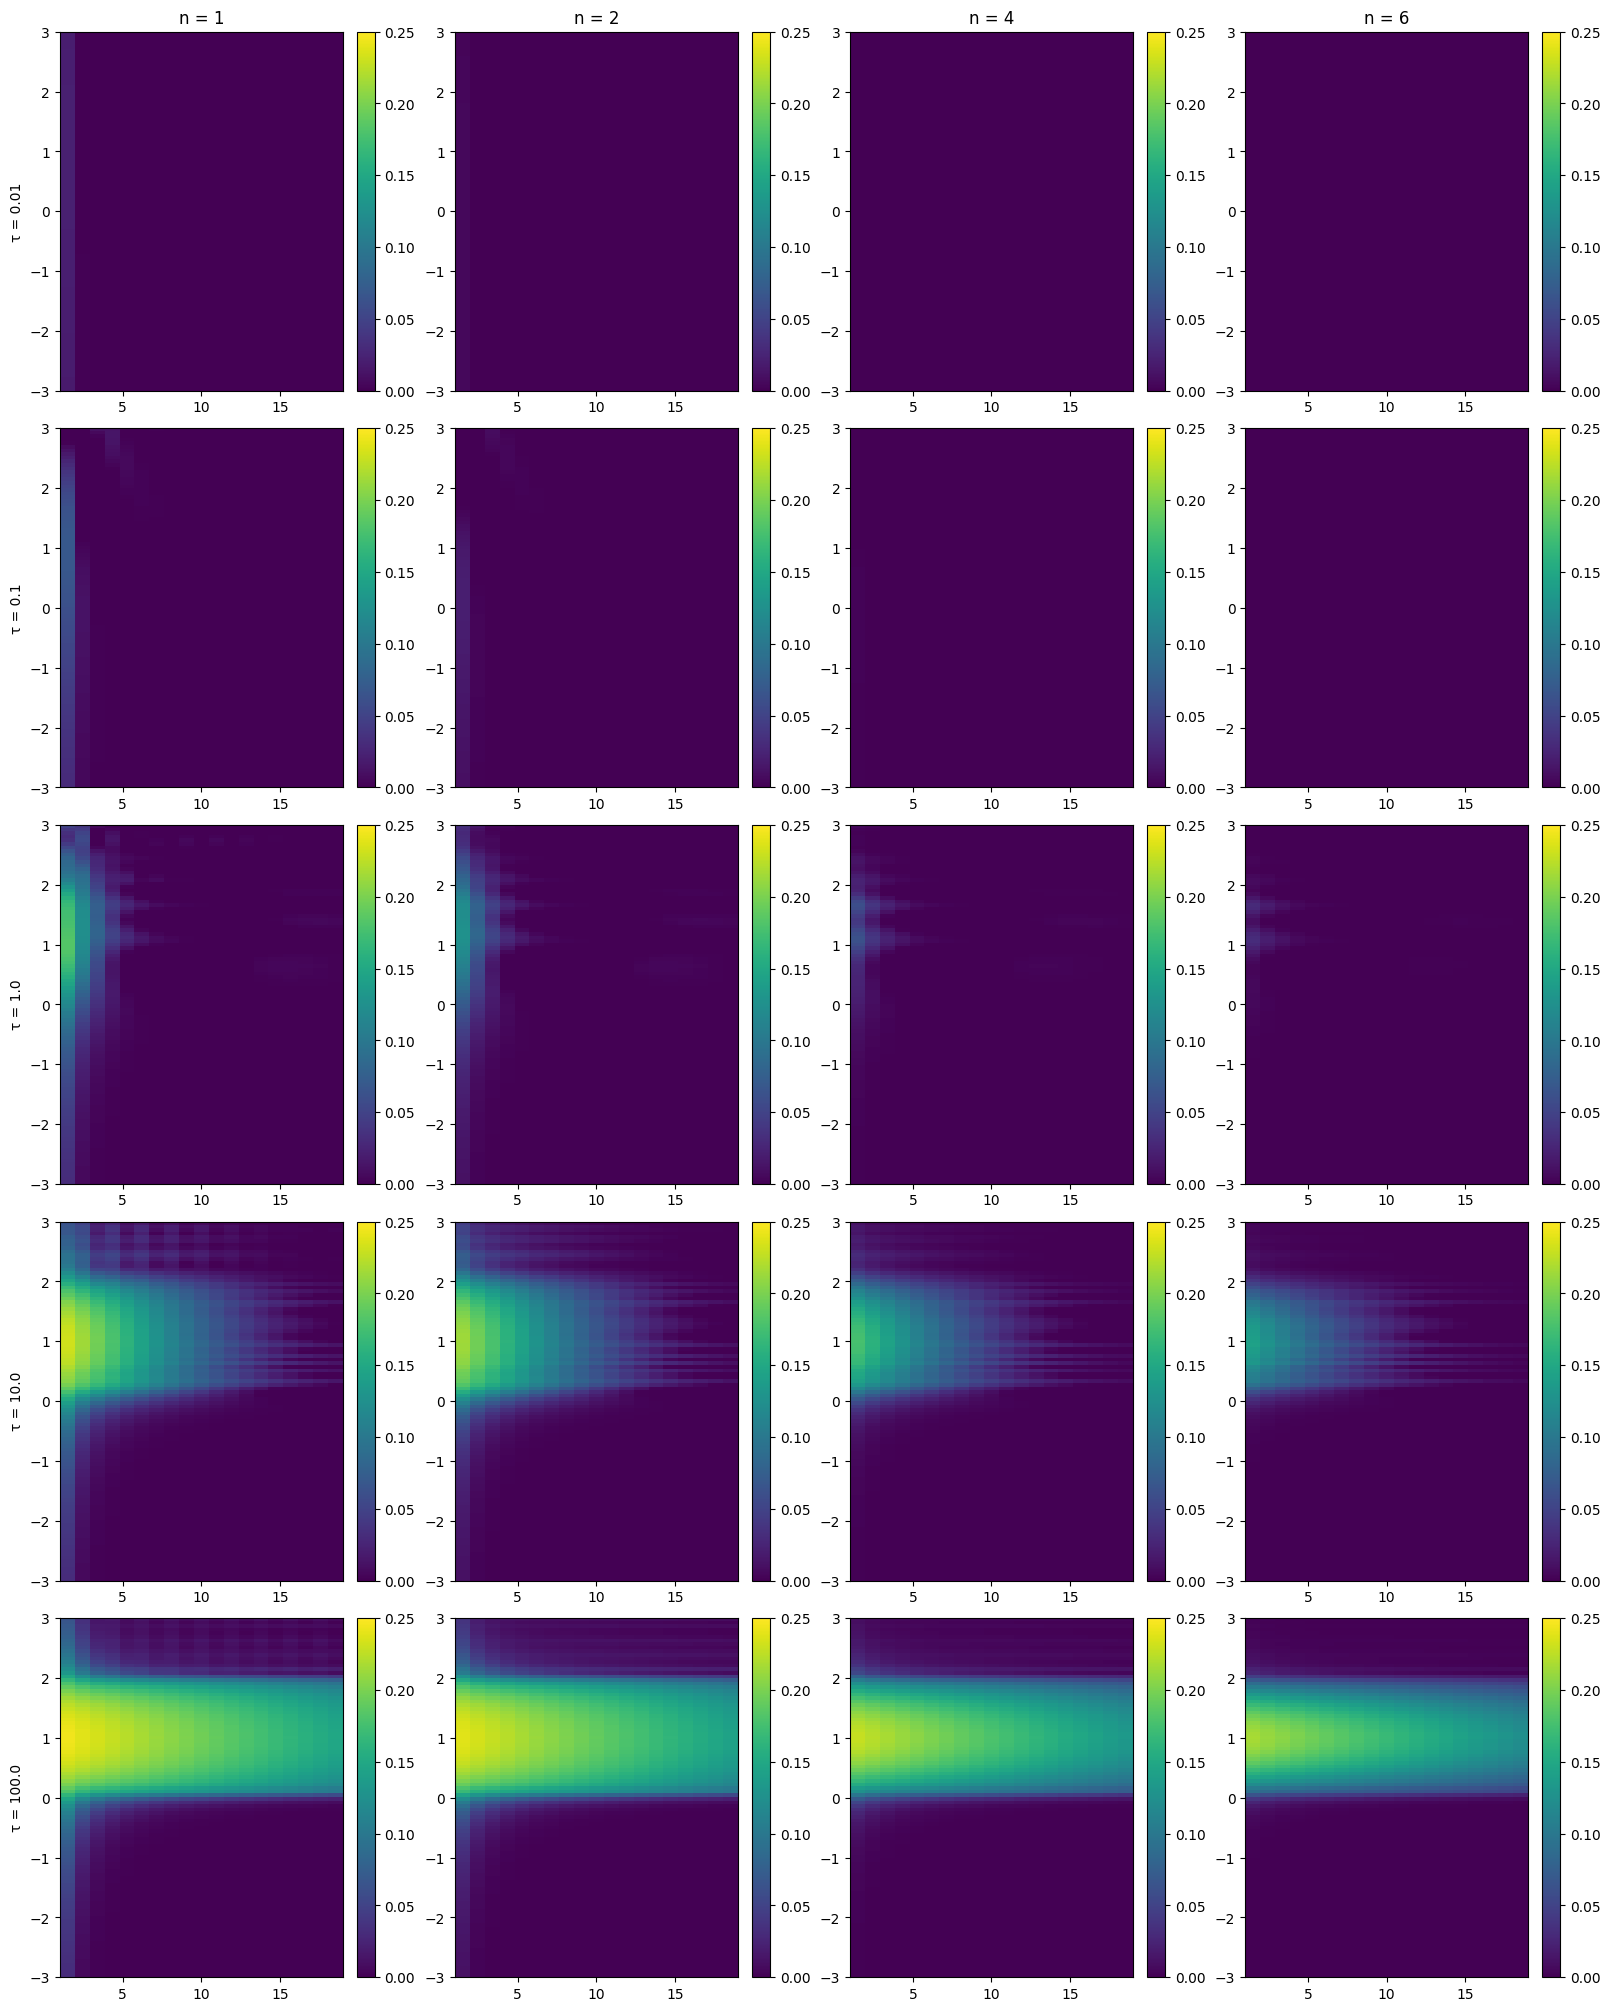

In [49]:
dat = []
unconnected = []
for n in [1, 2, 4, 6]:
    PP_data = np.load(f"Data/n={n}_PP_correlator.npz")
    unconnected_correlator = np.load(f"Data/n={n}_unconnected_correlator.npz")
    taus = PP_data["taus"]
    t_range = PP_data["t_range"]
    positions = PP_data["r"]
    PP = PP_data["data"]  # shape: (len(taus), len(t), len(r))
    P2 = unconnected_correlator["data"]
    dat.append(PP)
    unconnected.append(P2)

n_n = len(dat)            # Number of n values (columns)
n_tau = len(taus)         # Number of tau values (rows)

fig, axes = plt.subplots(n_tau, n_n, figsize=(4 * n_n, 4 * n_tau), constrained_layout=True)

for col in range(n_n):
    for row in range(n_tau):
        ax = axes[row, col]
        im = ax.imshow(dat[col][row,:,:]-unconnected[col][row,:,:], norm="linear", aspect="auto", origin="lower",
                       extent=[positions[0], positions[-1], t_range[0], t_range[-1]],
                       vmin=0, vmax=0.25)
        if col == 0:
            ax.set_ylabel(f"τ = {taus[row]}")
        if row == 0:
            ax.set_title(f"n = {[1,2,4,6][col]}")
        fig.colorbar(im, ax=ax)

plt.show()


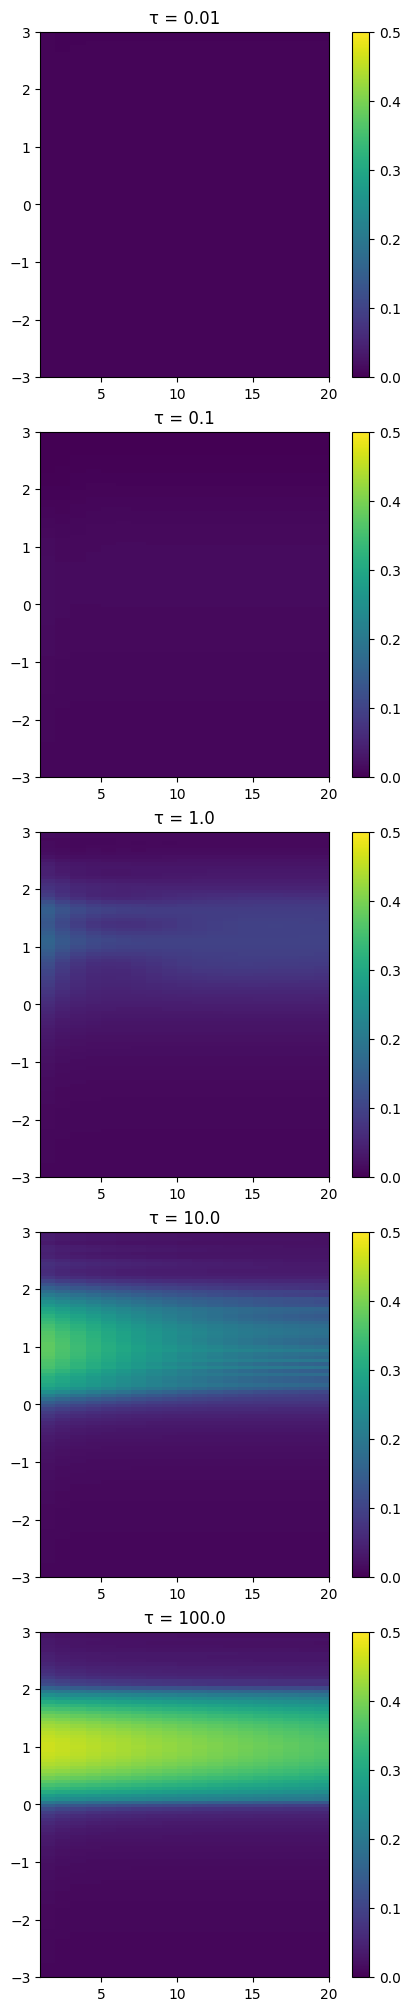

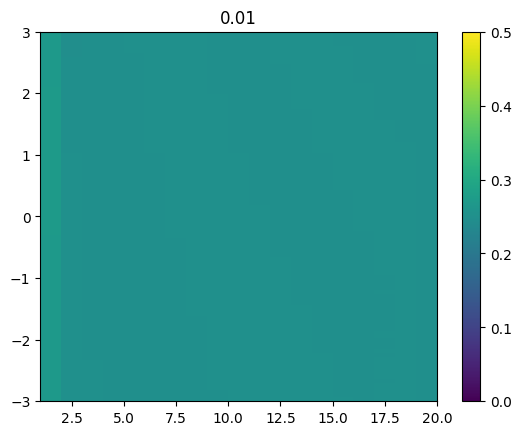

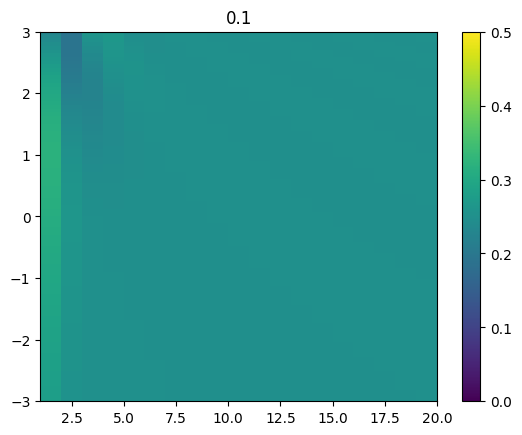

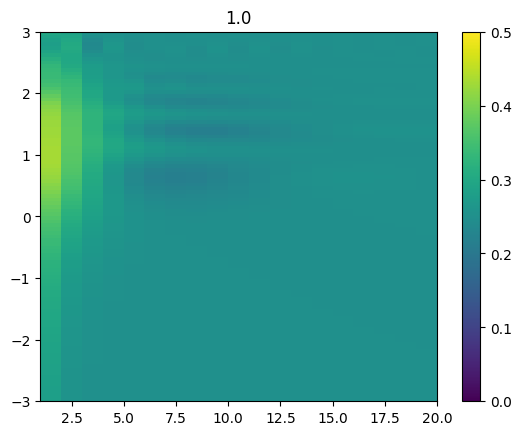

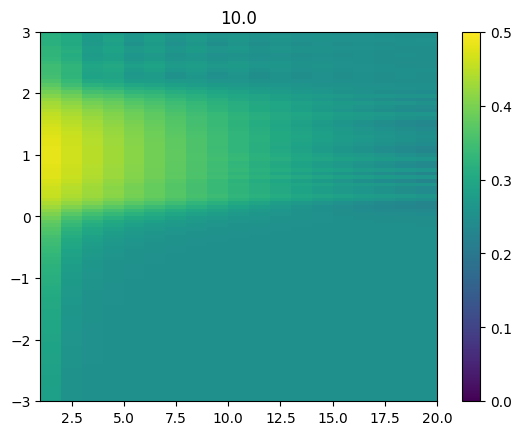

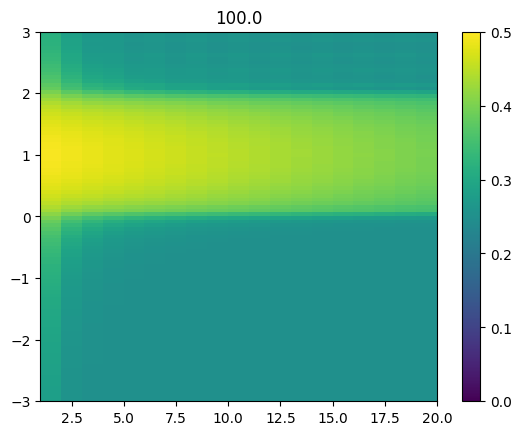

In [35]:
for i in range(len(taus)):
    tau = taus[i]

    plt.imshow(PP[i,:,:],norm="linear",aspect="auto",origin="lower",extent=[1,20,t_range[0],t_range[-1]],vmin=0,vmax=.5)
    plt.title(tau)
    plt.colorbar()
    plt.show()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])